# From Earth to Plate - Notebook 05: The personal playbook

**Maurice Baz & Dominika Bondyra - JH Data Patterns and Representations, final project**

This notebook builds **deck slide 9** (the falling action of the deck): the personal playbook.
After the earlier notebooks establish that food is a major emissions lever and that the gap
between animal- and plant-based foods is enormous, this notebook answers the audience's natural
question: *"OK - what can I actually do?"* Its framing: **recurring substitutions add up, while
waste prevention protects resources already invested in food.**

Two quantitative pieces:

1. **Per-kg substitution table** - the estimated footprint difference per kg substituted, for a
   curated list of realistic substitutions (the full ranking chart lives in the appendix).
2. **Realistic adoption scenarios** - what one weekly beef meal, or half of annual beef
   consumption, is worth per person per year as an estimated production-footprint difference
   under a 1:1 substitution.

Waste prevention stays in the playbook as a **qualitative** action: preventing food from going
unsold or uneaten protects the land, water, energy, and emissions already invested in it.

## Slide-to-figure mapping

| Deck slot | Figure | File |
|---|---|---|
| Slide 9 (main) | Realistic adoption scenarios | `figures/fig_slide09_practical_scenarios.png` |
| Appendix | Full 11-substitution per-kg ranking | `figures/fig_appendix_slide09_all_swaps.png` |


## Data

- **`data/Food_Product_Emissions.csv`** - 43 food products, supply-chain GHG emissions in
  kg CO2e per kg of food (Poore & Nemecek 2018, *Science*, as distributed via Our World in Data).
- **`data/ReFED_surplus_table(Surplus Data).csv`** - US surplus food by sector (ReFED 2024
  data, published in 2025 sector fact sheets). Used only in the appendix, for the
  residential-surplus context number. ReFED's measure is **surplus food** - food and inedible
  parts sent to donation, animal feed, repurposing, composting, anaerobic digestion, and
  disposal - not simply "waste".

**Emissions basis (project decision).** All per-kg numbers use the **"Total from Land to
Retail"** column - the land-to-retail total covering the seven supply-chain stages from land
use change through retail. On this basis beef (beef herd) = 59.57 and peas = 0.896 kg CO2e per
kg - the roughly 60:1 contrast used across the deck. The source file also provides a "Total
Global Average GHG Emissions per kg" column (beef = 99.48); the repository does not document
the exact scope difference between the two totals, so this notebook stays on land-to-retail
throughout and never mixes bases.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths resolve whether the notebook runs from the repo root or from notebooks/
ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA, FIGS = ROOT / 'data', ROOT / 'figures'
FIGS.mkdir(exist_ok=True)

# ---- house style (shared across all four notebooks) ----
INK      = '#0b0b0b'   # primary ink (titles)
INK2     = '#52514e'   # secondary ink (subtitles, value labels)
MUTED    = '#898781'   # axis ticks/titles, captions
SURFACE  = '#fcfcfb'   # figure + axes background
GRID     = '#e1e0d9'   # hairline grid
AXISLINE = '#c3c2b7'   # baseline/axis line
BLUE       = '#2a78d6' # sequential default (also semantic: animal-based)
BLUE_EMPH  = '#104281' # sequential emphasized
BLUE_LIGHT = '#9ec5f4' # sequential de-emphasized
GREEN      = '#008300' # semantic: plant-based

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans'],
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.edgecolor': AXISLINE, 'axes.linewidth': 0.8,
    'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'xtick.labelcolor': MUTED, 'ytick.labelcolor': MUTED,
    'axes.spines.top': False, 'axes.spines.right': False,
})


In [2]:
per_kg = pd.read_csv(DATA / 'Food_Product_Emissions.csv')
refed  = pd.read_csv(DATA / 'ReFED_surplus_table(Surplus Data).csv').dropna(how='all')
# The GHG header arrives mojibaked from the source export - rename it to ASCII on load.
refed.columns = ['GHG (MMt CO2e)' if 'GHG' in c else c for c in refed.columns]
assert 'GHG (MMt CO2e)' in refed.columns

BASIS = 'Total from Land to Retail'          # project-wide emissions basis
ltr = per_kg.set_index('Food product')[BASIS]

# Sanity checks: the basis decision reproduces the deck's headline contrast.
assert len(per_kg) == 43 and per_kg.isna().sum().sum() == 0
beef, peas = ltr['Beef (beef herd)'], ltr['Peas']
owid_avg_beef = per_kg.set_index('Food product').loc[
    'Beef (beef herd)', 'Total Global Average GHG Emissions per kg']
print(f'Beef (beef herd) land-to-retail: {beef:.2f} kg CO2e/kg')
print(f'Peas land-to-retail:             {peas:.3f} kg CO2e/kg')
print(f'Beef:peas ratio:                 {beef/peas:.1f}:1  (the roughly 60:1 contrast)')
print(f"(The source file also provides 'Total Global Average GHG Emissions per kg' - beef = "
      f"{owid_avg_beef:.2f}. The repository does not document the exact scope difference "
      f"between the two totals, so this notebook stays on land-to-retail throughout.)")
refed


Beef (beef herd) land-to-retail: 59.57 kg CO2e/kg
Peas land-to-retail:             0.896 kg CO2e/kg
Beef:peas ratio:                 66.5:1  (the roughly 60:1 contrast)
(The source file also provides 'Total Global Average GHG Emissions per kg' - beef = 99.48. The repository does not document the exact scope difference between the two totals, so this notebook stays on land-to-retail throughout.)


,Sector,Surplus (M tons),% of total,GHG (MMt CO2e),Value ($B)
0,Residential,23.50,33.2%,100.00,141.0
1,Farm,16.90,23.9%,3.56,13.4
2,Manufacturing,13.20,18.6%,38.60,42.7
3,Foodservice,12.50,17.7%,63.60,157.0
4,Retail,4.63,6.5%,15.10,30.3


## Analysis A - Estimated footprint difference per kg substituted

For each substitution we subtract the "to" food's land-to-retail intensity from the "from"
food's and report the difference: the **estimated footprint difference per kg substituted**.
The list is curated to be realistic (protein for protein, drink for drink): beef to plant
proteins, beef to other meats, then lamb / cheese / dairy-herd beef / shrimp to lighter
alternatives, plus two deliberately modest substitutions (milk -> soymilk, pork -> chicken) to
show the scale gap *within* the playbook. Legumes are represented by the **"Other Pulses"**
food product.

Substitutions are **mass-for-mass** (1 kg replaced by 1 kg). That is a transparent scenario -
the arithmetic is easy to audit - but it is **not nutritionally equivalent**: a kilogram of
pulses is not a kilogram of beef in protein or calories. (Notebook 01's per-protein analysis,
beef:peas = 113:1 per 100 g protein vs ~66:1 per kg here, shows the ranking direction is the
same under protein accounting.) These are estimated differences in production footprints under
a stated substitution, not measured real-world emission reductions.

The full ranking chart is an **appendix** figure; the main slide-9 figure comes from the
adoption scenarios in Analysis B.


In [3]:
swap_list = [
    ('Beef (beef herd)',  'Other Pulses',  'Beef -> legumes'),
    ('Beef (beef herd)',  'Tofu',          'Beef -> tofu'),
    ('Beef (beef herd)',  'Fish (farmed)', 'Beef -> fish (farmed)'),
    ('Beef (beef herd)',  'Poultry Meat',  'Beef -> chicken'),
    ('Beef (beef herd)',  'Pig Meat',      'Beef -> pork'),
    ('Lamb & Mutton',     'Poultry Meat',  'Lamb -> chicken'),
    ('Cheese',            'Tofu',          'Cheese -> tofu'),
    ('Beef (dairy herd)', 'Poultry Meat',  'Beef (dairy) -> chicken'),
    ('Shrimps (farmed)',  'Fish (farmed)', 'Shrimp -> fish (farmed)'),
    ('Milk',              'Soymilk',       'Milk -> soymilk'),
    ('Pig Meat',          'Poultry Meat',  'Pork -> chicken'),
]
swaps = pd.DataFrame(
    [{'swap': lbl, 'from': f, 'to': t,
      'from_kgCO2e': ltr[f], 'to_kgCO2e': ltr[t], 'est_diff_kg_per_kg': ltr[f] - ltr[t]}
     for f, t, lbl in swap_list]
).sort_values('est_diff_kg_per_kg', ascending=False).reset_index(drop=True)

# Assertions: expected row count; every ranked estimated difference is positive.
assert len(swaps) == len(swap_list) == 11
assert (swaps['est_diff_kg_per_kg'] > 0).all()

top = swaps['est_diff_kg_per_kg'].max()
r_milk = top / swaps.loc[swaps['swap'] == 'Milk -> soymilk', 'est_diff_kg_per_kg'].iloc[0]
r_pork = top / swaps.loc[swaps['swap'] == 'Pork -> chicken', 'est_diff_kg_per_kg'].iloc[0]
print(f'Largest estimated footprint difference (beef -> legumes, i.e. Other Pulses): '
      f'{top:.2f} kg CO2e per kg substituted')
print(f'Milk -> soymilk is {r_milk:.0f}x smaller; pork -> chicken is {r_pork:.0f}x smaller')
swaps.round(2)


Largest estimated footprint difference (beef -> legumes, i.e. Other Pulses): 57.96 kg CO2e per kg substituted
Milk -> soymilk is 31x smaller; pork -> chicken is 49x smaller


,swap,from,to,from_kgCO2e,to_kgCO2e,est_diff_kg_per_kg
0,Beef -> legumes,Beef (beef herd),Other Pulses,59.57,1.61,57.96
1,Beef -> tofu,Beef (beef herd),Tofu,59.57,2.87,56.70
2,Beef -> fish (farmed),Beef (beef herd),Fish (farmed),59.57,5.18,54.39
3,Beef -> chicken,Beef (beef herd),Poultry Meat,59.57,6.09,53.48
4,Beef -> pork,Beef (beef herd),Pig Meat,59.57,7.28,52.29
5,Cheese -> tofu,Cheese,Tofu,21.24,2.87,18.37
6,Lamb -> chicken,Lamb & Mutton,Poultry Meat,24.42,6.09,18.32
7,Beef (dairy) -> chicken,Beef (dairy herd),Poultry Meat,21.08,6.09,14.99
8,Shrimp -> fish (farmed),Shrimps (farmed),Fish (farmed),11.85,5.18,6.67
9,Milk -> soymilk,Milk,Soymilk,2.78,0.91,1.87


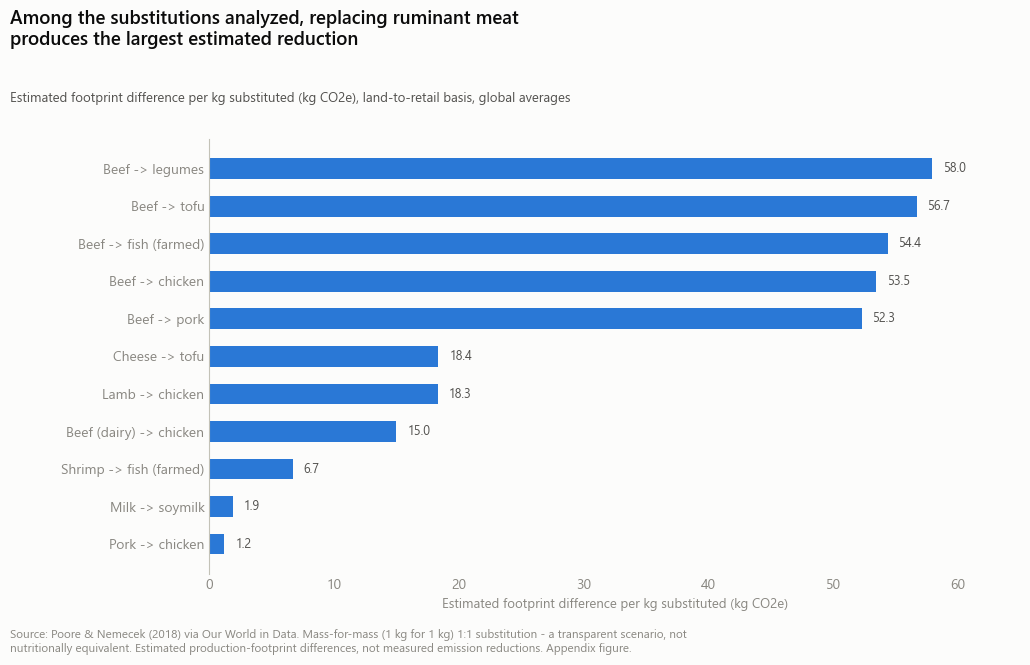

In [4]:
d = swaps.sort_values('est_diff_kg_per_kg')        # ascending -> largest bar on top
fig, ax = plt.subplots(figsize=(10.6, 6.6))
fig.subplots_adjust(left=0.20, right=0.965, top=0.79, bottom=0.13)

ax.barh(d['swap'], d['est_diff_kg_per_kg'], height=0.55, color=BLUE)  # one measure -> one hue

ax.grid(axis='x')                                  # grid only along the value axis
ax.grid(axis='y', visible=False)
for s in ('top', 'right', 'bottom'):
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(AXISLINE)              # categorical baseline
ax.tick_params(length=0)
ax.set_xlim(0, 65)
ax.set_xticks([0, 10, 20, 30, 40, 50, 60])
ax.set_xlabel('Estimated footprint difference per kg substituted (kg CO2e)', fontsize=9.5)

for y, v in enumerate(d['est_diff_kg_per_kg']):    # direct value labels at bar tips
    ax.text(v + 0.9, y, f'{v:,.1f}', va='center', fontsize=9, color=INK2)

fig.text(0.012, 0.985,
         'Among the substitutions analyzed, replacing ruminant meat\n'
         'produces the largest estimated reduction',
         va='top', fontsize=13.5, fontweight=600, color=INK)
fig.text(0.012, 0.845,
         'Estimated footprint difference per kg substituted (kg CO2e), land-to-retail basis, '
         'global averages',
         fontsize=9.5, color=INK2)
fig.text(0.012, 0.012,
         'Source: Poore & Nemecek (2018) via Our World in Data. Mass-for-mass (1 kg for 1 kg) '
         '1:1 substitution - a transparent scenario, not\nnutritionally equivalent. Estimated '
         'production-footprint differences, not measured emission reductions. Appendix figure.',
         fontsize=8.5, color=MUTED)

fig.savefig(FIGS / 'fig_appendix_slide09_all_swaps.png')
plt.show()


**Takeaway.** Among the substitutions analyzed, replacing ruminant meat produces the largest
estimated reduction. Replacing beef (beef herd) shows an estimated footprint difference of
**57.96 kg CO2e per kg substituted** going to legumes (Other Pulses), 56.7 to tofu, 54.4 to
farmed fish, 53.5 to chicken - and even staying with meat, beef -> pork is ~52.3 kg per kg.
The middle tier (cheese -> tofu 18.4, lamb -> chicken 18.3, dairy-herd beef -> chicken 15.0)
is roughly a third of that, and the everyday-sounding substitutions - milk -> soymilk (1.87)
and pork -> chicken (1.19) - are 31x and 49x smaller than beef -> legumes. All values are
estimated production-footprint differences under a 1:1 substitution on the land-to-retail
basis.


## Analysis B - Realistic adoption scenarios

Per-kg numbers are abstract; a year of actual meals is not. We model four adoption scenarios a
single person could realistically carry out, computed from the loaded data with two
serving-level constants - a 4-oz serving (`FOUR_OZ_KG` = 4 x 28.349523125 g = 0.1134 kg) and
52 weekly meals per year - plus the US-average per-capita beef consumption of **26.35 kg
retail weight per year** (58.1 lb; USDA Economic Research Service, 2023 actual - 2024
estimated unchanged). Legumes are represented by the **"Other Pulses"** food product, the same
product used for the beef -> legumes substitution in Analysis A.

1. One 4-oz beef meal per week replaced with chicken (poultry) - about 5.9 kg of beef per year.
2. One 4-oz beef meal per week replaced with legumes (Other Pulses).
3. Half of annual average per-capita beef (13.18 kg) replaced with chicken.
4. Half of annual average per-capita beef replaced with legumes (Other Pulses).

Every value is an **estimated production-footprint difference under a 1:1 substitution** - a
transparent scenario, but not nutritionally equivalent, and not a claim of measured real-world
emission reductions. The full (100%) replacement of annual beef appears **only in the
appendix**, as an explicit upper bound.


In [5]:
# Serving-level constants for the adoption scenarios
FOUR_OZ_KG     = 4 * 28.349523125 / 1000   # one 4-oz serving in kg (exact avoirdupois ounce)
MEALS_PER_YEAR = 52                        # one meal per week
BEEF_KG_PER_YR = 26.35   # kg/person/yr = 58.1 lb retail weight, 2023 actual (USDA ERS; 2024 est. unchanged)

LEGUME_PRODUCT = 'Other Pulses'            # the food product representing legumes throughout
diff_chicken = ltr['Beef (beef herd)'] - ltr['Poultry Meat']
diff_legumes = ltr['Beef (beef herd)'] - ltr[LEGUME_PRODUCT]

weekly_kg_yr = FOUR_OZ_KG * MEALS_PER_YEAR   # kg beef replaced per year, weekly-meal scenarios
half_kg_yr   = BEEF_KG_PER_YR / 2            # kg beef replaced per year, half-of-annual scenarios

scenarios = pd.DataFrame({
    'scenario': ['One 4-oz beef meal/week -> chicken',
                 f'One 4-oz beef meal/week -> legumes ({LEGUME_PRODUCT})',
                 'Half of annual beef -> chicken',
                 f'Half of annual beef -> legumes ({LEGUME_PRODUCT})'],
    'kg_beef_replaced_per_yr': [weekly_kg_yr, weekly_kg_yr, half_kg_yr, half_kg_yr],
    'per_kg_diff': [diff_chicken, diff_legumes, diff_chicken, diff_legumes],
})
scenarios['est_diff_kgCO2e_per_yr'] = (scenarios['kg_beef_replaced_per_yr']
                                       * scenarios['per_kg_diff'])

# Cross-checks on the scenario arithmetic
assert abs(weekly_kg_yr - FOUR_OZ_KG * 52) < 1e-9   # weekly-meal kg/yr == FOUR_OZ_KG * 52
assert np.allclose(scenarios['est_diff_kgCO2e_per_yr'],
                   scenarios['kg_beef_replaced_per_yr'] * scenarios['per_kg_diff'])
assert (scenarios['est_diff_kgCO2e_per_yr'] > 0).all()

print(f'4-oz serving = {FOUR_OZ_KG:.6f} kg; weekly-meal scenarios replace '
      f'{weekly_kg_yr:.3f} kg beef/yr')
print(f'Half-of-annual scenarios replace {half_kg_yr:.3f} kg beef/yr '
      f'(of {BEEF_KG_PER_YR} kg total)')
for _, row in scenarios.iterrows():
    print(f"  {row['scenario']:<52s} est. {row['est_diff_kgCO2e_per_yr']:7.1f} kg CO2e/yr")
scenarios.round(2)


4-oz serving = 0.113398 kg; weekly-meal scenarios replace 5.897 kg beef/yr
Half-of-annual scenarios replace 13.175 kg beef/yr (of 26.35 kg total)
  One 4-oz beef meal/week -> chicken                   est.   315.3 kg CO2e/yr
  One 4-oz beef meal/week -> legumes (Other Pulses)    est.   341.8 kg CO2e/yr
  Half of annual beef -> chicken                       est.   704.6 kg CO2e/yr
  Half of annual beef -> legumes (Other Pulses)        est.   763.6 kg CO2e/yr


,scenario,kg_beef_replaced_per_yr,per_kg_diff,est_diff_kgCO2e_per_yr
0,One 4-oz beef meal/week -> chicken,5.90,53.48,315.34
1,One 4-oz beef meal/week -> legumes (Other Pulses),5.90,57.96,341.77
2,Half of annual beef -> chicken,13.18,53.48,704.57
3,Half of annual beef -> legumes (Other Pulses),13.18,57.96,763.62


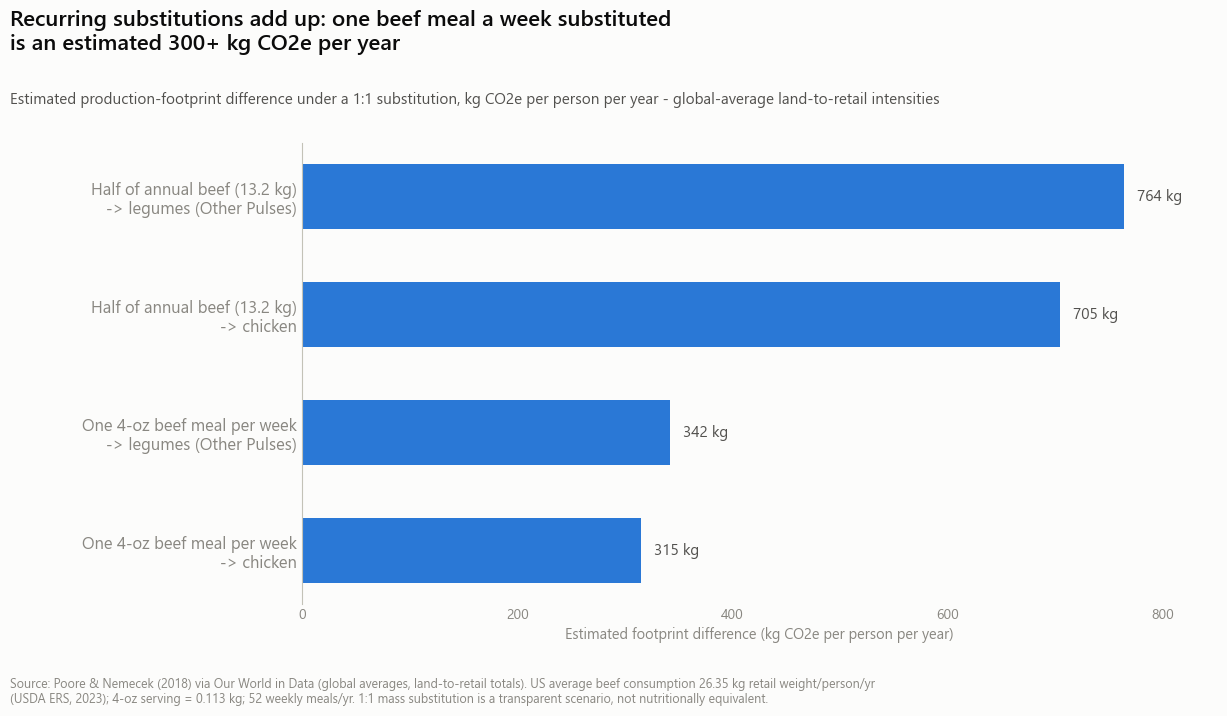

In [6]:
wrap = {
    'One 4-oz beef meal/week -> chicken':
        'One 4-oz beef meal per week\n-> chicken',
    f'One 4-oz beef meal/week -> legumes ({LEGUME_PRODUCT})':
        'One 4-oz beef meal per week\n-> legumes (Other Pulses)',
    'Half of annual beef -> chicken':
        'Half of annual beef (13.2 kg)\n-> chicken',
    f'Half of annual beef -> legumes ({LEGUME_PRODUCT})':
        'Half of annual beef (13.2 kg)\n-> legumes (Other Pulses)',
}
d = scenarios.sort_values('est_diff_kgCO2e_per_yr')  # ascending -> largest bar on top
ylabels = d['scenario'].map(wrap)

fig, ax = plt.subplots(figsize=(12.8, 7.2))
fig.subplots_adjust(left=0.24, right=0.955, top=0.79, bottom=0.15)

ax.barh(ylabels, d['est_diff_kgCO2e_per_yr'], height=0.55, color=BLUE)  # one measure -> one hue

ax.grid(axis='x')
ax.grid(axis='y', visible=False)
for s in ('top', 'right', 'bottom'):
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(AXISLINE)
ax.tick_params(length=0)
ax.tick_params(axis='y', labelsize=12)
ax.set_xlim(0, 850)
ax.set_xticks([0, 200, 400, 600, 800])
ax.set_xlabel('Estimated footprint difference (kg CO2e per person per year)', fontsize=10.5)

for y, v in enumerate(d['est_diff_kgCO2e_per_yr']):   # direct value labels at bar tips
    ax.text(v + 12, y, f'{v:,.0f} kg', va='center', fontsize=11, color=INK2)

fig.text(0.012, 0.975,
         'Recurring substitutions add up: one beef meal a week substituted\n'
         'is an estimated 300+ kg CO2e per year',
         va='top', fontsize=16, fontweight=600, color=INK)
fig.text(0.012, 0.845,
         'Estimated production-footprint difference under a 1:1 substitution, kg CO2e per '
         'person per year - global-average land-to-retail intensities',
         fontsize=11, color=INK2)
fig.text(0.012, 0.012,
         'Source: Poore & Nemecek (2018) via Our World in Data (global averages, '
         'land-to-retail totals). US average beef consumption 26.35 kg retail weight/person/yr\n'
         '(USDA ERS, 2023); 4-oz serving = 0.113 kg; 52 weekly meals/yr. 1:1 mass substitution '
         'is a transparent scenario, not nutritionally equivalent.',
         fontsize=9, color=MUTED)

fig.savefig(FIGS / 'fig_slide09_practical_scenarios.png')
plt.show()


**Takeaway.** Recurring substitutions add up, while waste prevention protects resources
already invested in food. One 4-oz beef meal per week substituted for a year is an estimated
**315 kg CO2e (to chicken)** or **342 kg CO2e (to legumes, Other Pulses)** production-footprint
difference; substituting half of annual average beef reaches an estimated **705 kg (chicken)**
or **764 kg (legumes)** per year. Alongside the substitutions, **waste prevention belongs in
the playbook as a qualitative action**: buying what you will actually eat, storing it well, and
using leftovers protects the land, water, energy, and emissions already invested in food -
value that is lost whenever food goes uneaten. The appendix holds the two context numbers kept
off the main slide: the full-replacement upper bound and the residential-surplus per-resident
figure.


## Appendix - upper bound and context

Two numbers deliberately kept off the main slide:

1. **Full-replacement upper bound.** Replacing 100% of annual average per-capita beef is an
   explicit *upper bound* on the substitution scenarios, not a realistic adoption assumption -
   it is computed below and labeled as such.
2. **Residential surplus context.** ReFED 2024 data, published in 2025 sector fact sheets, put
   US **residential** surplus-food GHG at 100 MMt CO2e per year. Divided evenly across 340.1
   million residents (U.S. Census Bureau, Vintage 2024 Population Estimates, July 1, 2024),
   that is ~294 kg CO2e per resident per year: **"Average GHG associated with residential
   surplus per U.S. resident - contextual upper bound, not all individually preventable."**
   Surplus food includes food and inedible parts sent to donation, animal feed, repurposing,
   composting, anaerobic digestion, and disposal - this is an even per-capita allocation of a
   sector-level estimate, not a personal reduction number.


In [7]:
# Appendix 1 - UPPER BOUND: full (100%) replacement of annual average per-capita beef.
upper_bound = pd.DataFrame({
    'scenario (appendix upper bound)': [
        '100% of annual beef -> chicken',
        f'100% of annual beef -> legumes ({LEGUME_PRODUCT})'],
    'kg_beef_replaced_per_yr': [BEEF_KG_PER_YR] * 2,
    'est_diff_kgCO2e_per_yr': [BEEF_KG_PER_YR * diff_chicken, BEEF_KG_PER_YR * diff_legumes],
})
print('Appendix upper bound - full (100%) replacement of annual average per-capita beef')
print('(an explicit upper bound on the substitution scenarios, not realistic adoption):')
print(upper_bound.round(2).to_string(index=False))

# Appendix 2 - residential surplus context (ReFED 2024 data, published in 2025 sector fact sheets)
US_POP_M    = 340.1   # millions, July 1 2024 (US Census Bureau, Vintage 2024 Population Estimates)
res_ghg_mmt = refed.loc[refed['Sector'] == 'Residential', 'GHG (MMt CO2e)'].iloc[0]
res_per_resident_kg = res_ghg_mmt * 1e9 / (US_POP_M * 1e6)   # 1 MMt = 1e9 kg

print()
print('Average GHG associated with residential surplus per U.S. resident - contextual '
      'upper bound, not all individually preventable.')
print(f'  {res_ghg_mmt:.0f} MMt CO2e residential surplus GHG / {US_POP_M:.1f}M residents '
      f'= {res_per_resident_kg:.0f} kg CO2e per resident per year')
print('  Source: ReFED 2024 data, published in 2025 sector fact sheets.')


Appendix upper bound - full (100%) replacement of annual average per-capita beef
(an explicit upper bound on the substitution scenarios, not realistic adoption):
              scenario (appendix upper bound)  kg_beef_replaced_per_yr  est_diff_kgCO2e_per_yr
               100% of annual beef -> chicken                    26.35                 1409.15
100% of annual beef -> legumes (Other Pulses)                    26.35                 1527.25

Average GHG associated with residential surplus per U.S. resident - contextual upper bound, not all individually preventable.
  100 MMt CO2e residential surplus GHG / 340.1M residents = 294 kg CO2e per resident per year
  Source: ReFED 2024 data, published in 2025 sector fact sheets.


## Assumptions table

| # | Assumption | Value used | Basis / source | Status |
|---|------------|------------|----------------|--------|
| 1 | US per-capita beef consumption | 26.35 kg/person/yr (58.1 lb, retail weight, 2023 actual; 2024 estimated unchanged) | USDA Economic Research Service, per-capita beef consumption (retail weight) | Source-verified |
| 2 | Emissions basis | "Total from Land to Retail" (land-to-retail total), kg CO2e per kg food | Poore & Nemecek (2018); project-wide basis decision | Fixed by project |
| 3 | Serving size | 4 oz = 4 x 28.349523125 g = 0.1134 kg | Exact avoirdupois-ounce conversion | Fixed |
| 4 | Meal frequency | 52 meals per year (one per week) | Scenario definition | Scenario choice |
| 5 | Legume representative | "Other Pulses" (1.61 kg CO2e/kg, land-to-retail) | Same product as the Analysis A beef -> legumes substitution | Fixed by project |
| 6 | Substitution accounting | Mass-for-mass: 1 kg of the "from" food replaced by 1 kg of the "to" food | Simplicity and transparency | Transparent scenario - not nutritionally equivalent |
| 7 | Residential surplus GHG (appendix only) | 100 MMt CO2e/yr (US residential sector) | ReFED 2024 data, published in 2025 sector fact sheets | As published |
| 8 | US population (appendix only) | 340.1 million (July 1, 2024) | U.S. Census Bureau, Vintage 2024 Population Estimates | Source-verified |

**Note on retail weight (row 1).** The 58.1 lb (26.35 kg) figure is retail weight, which
includes some bone and trim, so it slightly overstates bone-free intake relative to Poore &
Nemecek's per-kg functional unit - we use the standard retail-weight figure knowingly.

**Note on mass-for-mass (row 6).** Substituting 1 kg of beef with 1 kg of legumes is not
calorie- or protein-identical - the 1:1 scenario is used because it is transparent and easy to
audit, not because it is nutritionally equivalent. Notebook 01's per-protein analysis
(beef:peas = 113:1 per 100 g of protein vs ~66:1 per kg here) shows the ranking direction is
unchanged under protein accounting.

**Footnote on the basis column.** The source file also provides a "Total Global Average GHG
Emissions per kg" column (beef (beef herd) = 99.48 kg CO2e/kg). The repository does not
document the exact scope difference between that column and the land-to-retail total, so we
stay on land-to-retail for consistency across the deck and do not mix bases.


## Limitations

- **Global averages hide variance.** Poore & Nemecek pool ~38,000 farms; individual producers
  vary widely. The ranking is robust (even low-impact beef exceeds most plant proteins), but
  any single household's numbers will differ.
- **Estimated differences, not measured outcomes.** Every scenario value is an estimated
  production-footprint difference under a stated 1:1 substitution. Real dietary change involves
  substitution ratios, market and supply responses, and behavior effects not modeled here, so
  none of these values is a measured real-world emission reduction.
- **Mass-for-mass substitution is not nutritionally equivalent.** It is a transparent scenario;
  notebook 01's per-protein analysis (beef:peas = 113:1 per 100 g protein) shows the ranking
  direction persists under protein accounting.
- **The appendix residential-surplus figure is an even per-capita allocation** of a
  sector-level estimate (ReFED 2024 data, published in 2025 sector fact sheets). It is a
  contextual upper bound - not all of it is individually preventable, and household surplus
  varies a lot.
- **Basis scope.** The land-to-retail basis covers the seven supply-chain stages in the source
  file. The file's alternative "Total Global Average GHG Emissions per kg" column is higher for
  most foods (beef 99.48 vs 59.57), but the repository does not document the exact scope
  difference between the two totals, so we do not extrapolate beyond the land-to-retail basis.


## Sources

- Poore, J. & Nemecek, T. (2018). "Reducing food's environmental impacts through producers and
  consumers." *Science* 360(6392), 987-992. Data as distributed via Our World in Data
  (`data/Food_Product_Emissions.csv`).
- ReFED 2024 data, published in 2025 sector fact sheets - US surplus food by sector
  (`data/ReFED_surplus_table(Surplus Data).csv`). Surplus food includes food and inedible
  parts sent to donation, animal feed, repurposing, composting, anaerobic digestion, and
  disposal.
- USDA Economic Research Service, per-capita beef consumption (retail weight): 58.1 lb
  (26.35 kg) per person, 2023 (2024 estimated unchanged).
- U.S. Census Bureau, Vintage 2024 Population Estimates: 340.1 million (July 1, 2024). Used
  only for the appendix residential-surplus context number.
